1. **Janela Temporal Canônica de Vendas:** Toda métrica e base satélite é delimitada estritamente pelo intervalo de vendas ($T_{\text{início}} = \min(\text{data\_pedido})$ e $T_{\text{fim}} = \max(\text{data\_pedido})$).
   - **Estoque:** Limitado por `data_ultima_entrada <= end_date`. O cálculo de **Giro de Estoque** considera estritamente os SKUs com entrada registrada até o fechamento da janela de vendas, eliminando a distorção de calcular giro com estoque sem vendas.
   - **Clientes:** Limitado por `data_cadastro <= end_date`, analisando o LTV, Recompra e Churn na coorte de clientes ativos.
   - **Marketing:** Limitado por `data_fim <= end_date` (e `data_inicio >= start_date`), apurando o CAC e ROAS estritamente nas campanhas concluídas no ciclo de vendas.
   - **Atendimento:** Limitado por `data_fechamento <= end_date` (e `data_abertura >= start_date`), garantindo que o volume de chamados, tickets WISMO, custo por ticket e SLA correspondam ao ciclo operacional de vendas.

2. **Dupla Camada de Avaliação (Dual-Layer Metrics):**
   - **Camada A (Iniciativas Operacionais - Padrão `simulador_cenarios`):** Detalhamento das 5 alavancas operacionais (WISMO, Frete Crítico, Otimização de Mídia, Bundles Moda e Redução de Devoluções) com Capex, Impacto na Janela, Benefício Mensal e Payback em Meses.
   - **Camada B (Matriz Consolidada de 26 KPIs - Padrão `aaa.ipynb`):** Comparação direta da **Baseline (Realizado)** contra os cenários de estresse e estratégia (*Pessimista*, *Conservador*, *Agressivo*, *Foco em CX* e *Proteção de Caixa*).

In [3]:
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (15, 8)

import warnings
warnings.filterwarnings('ignore')

## 1. Motor Analítico de FP&A com Sincronização Estrita

A classe `MotorSimuladorIntegrado` resolve dinamicamente os caminhos de dados e sincroniza todas as bases pela janela temporal canônica de vendas.

In [4]:
class MotorSimuladorIntegrado:
    def __init__(self, caminho_dados=None):
        self.caminho_dados = self._resolver_caminho(caminho_dados)
        self.carregar_e_sincronizar_dados()
        self.kpis_base = {}
        self._calcular_baseline()

    def _resolver_caminho(self, caminho_dados):
        if caminho_dados and Path(caminho_dados).exists():
            return Path(caminho_dados)
        candidatos = [
            Path("../data"),
            Path("./data"),
            Path("."),
            Path("data")
        ]
        for c in candidatos:
            if (c / "vendas.csv").exists():
                return c
        return Path("../data")

    def carregar_e_sincronizar_dados(self):
        """Carrega os CSVs e aplica o filtro estrito de janela temporal ditado pelas vendas."""
        try:
            vendas_raw = pd.read_csv(self.caminho_dados / 'vendas.csv', parse_dates=['data_pedido'])
            clientes_raw = pd.read_csv(self.caminho_dados / 'clientes.csv', parse_dates=['data_cadastro', 'data_nascimento'])
            estoque_raw = pd.read_csv(self.caminho_dados / 'estoque.csv', parse_dates=['data_ultima_entrada'])
            marketing_raw = pd.read_csv(self.caminho_dados / 'marketing.csv', parse_dates=['data_inicio', 'data_fim'])
            atend_raw = pd.read_csv(self.caminho_dados / 'atendimento.csv', parse_dates=['data_abertura', 'data_fechamento'])

            # 1. Definição da Janela Canônica
            self.vendas = vendas_raw.dropna(subset=['data_pedido']).copy()
            self.start_date = self.vendas['data_pedido'].min()
            self.end_date = self.vendas['data_pedido'].max()
            self.window_days = max((self.end_date - self.start_date).days + 1, 1)
            self.window_months = max(self.window_days / 30.4375, 1.0)
            self.vendas['is_devolvido'] = self.vendas['devolvido'].fillna(False).astype(bool)

            # 2. Isolamento Temporal Rigoroso
            # Estoque limitado por data_ultima_entrada <= end_date (sem inflar giro com períodos sem venda)
            self.estoque = estoque_raw[estoque_raw['data_ultima_entrada'] <= self.end_date].copy()
            
            # Clientes limitados por data_cadastro <= end_date
            self.clientes = clientes_raw[clientes_raw['data_cadastro'] <= self.end_date].copy()
            
            # Marketing limitado por data_fim <= end_date (campanhas encerradas durante a janela de vendas)
            self.marketing = marketing_raw[
                (marketing_raw['data_fim'] <= self.end_date) & 
                (marketing_raw['data_inicio'] >= self.start_date)
            ].copy()
            
            # Atendimento limitado por data_fechamento <= end_date (tickets finalizados no ciclo de vendas)
            self.atend = atend_raw[
                (atend_raw['data_fechamento'] <= self.end_date) & 
                (atend_raw['data_abertura'] >= self.start_date)
            ].copy()

            print(f"[OK] Dados sincronizados com rigor temporal.")
            print(f"     Janela de Vendas: {self.start_date.strftime('%Y-%m-%d')} a {self.end_date.strftime('%Y-%m-%d')} ({self.window_months:.2f} meses)")
            print(f"     - Vendas válidas: {len(self.vendas):,} registros")
            print(f"     - Estoque ativo (<= fim vendas): {len(self.estoque):,} SKUs | {self.estoque['estoque_fisico'].sum():,} un. físicas")
            print(f"     - Clientes na janela: {len(self.clientes):,} registros")
            print(f"     - Campanhas Mídia encerradas na janela: {len(self.marketing):,} campanhas | R$ {self.marketing['investimento_reais'].sum():,.2f}")
            print(f"     - Tickets Atendimento concluídos na janela: {len(self.atend):,} chamados")
        except FileNotFoundError as e:
            print(f"[ERRO] Falha ao carregar CSVs: {e}")

    def _calcular_baseline(self):
        """Calcula rigorosamente a Baseline dos 26 KPIs canônicos sobre a janela isolada."""
        v = self.vendas
        c = self.clientes
        e = self.estoque
        m = self.marketing
        a = self.atend

        v_aprov = v[v['status_pagamento'] == 'Aprovado']
        c_ativos = c[c['customer_id'].isin(v['customer_id'].unique())]
        pedidos_totais = v['order_id'].nunique()
        receita_bruta = v['receita_bruta'].sum()
        margem_contribuicao = v['margem_contribuicao'].sum()
        estoque_fisico = e['estoque_fisico'].sum()

        # Comercial
        self.kpis_base['Receita Bruta (R$)'] = receita_bruta
        self.kpis_base['Pedidos Totais'] = pedidos_totais
        self.kpis_base['Ticket Médio (R$)'] = receita_bruta / pedidos_totais if pedidos_totais else 0.0
        cliques = m['cliques'].sum() if 'cliques' in m.columns else m['conversoes'].sum() * 50
        self.kpis_base['Taxa de Conversão Mídia (%)'] = (m['conversoes'].sum() / cliques) * 100 if cliques else 0.0

        # Margem
        self.kpis_base['Margem Contribuição (R$)'] = margem_contribuicao
        self.kpis_base['Margem Contribuição (%)'] = (margem_contribuicao / receita_bruta) * 100 if receita_bruta else 0.0
        self.kpis_base['Desconto Médio Pedido (R$)'] = v['desconto_reais'].sum() / pedidos_totais if pedidos_totais else 0.0
        self.kpis_base['Custo Frete Médio (R$)'] = v['custo_frete'].mean()
        v['rentab_sku'] = np.where(v['receita_bruta'] > 0, v['margem_contribuicao'] / v['receita_bruta'], 0.0)
        self.kpis_base['Rentabilidade Média SKU (%)'] = v['rentab_sku'].mean() * 100

        # Marketing
        self.kpis_base['Conversões Mídia'] = m['conversoes'].sum()
        inv_midia = m['investimento_reais'].sum()
        self.kpis_base['Investimento Mídia (R$)'] = inv_midia
        self.kpis_base['CAC Ponderado (R$)'] = inv_midia / self.kpis_base['Conversões Mídia'] if self.kpis_base['Conversões Mídia'] else 0.0
        self.kpis_base['ROAS Consolidado'] = v_aprov['receita_bruta'].sum() / inv_midia if inv_midia else 0.0

        # Clientes
        self.kpis_base['Taxa de Recompra (%)'] = (c_ativos['total_pedidos_historico'] > 1).mean() * 100 if len(c_ativos) else 0.0
        self.kpis_base['LTV Médio Coorte (R$)'] = c_ativos['ltv_acumulado'].mean() if len(c_ativos) else 0.0
        self.kpis_base['Churn Coorte (%)'] = c_ativos['segmento_rfm'].isin(['Em Risco', 'Hibernando']).mean() * 100 if len(c_ativos) else 0.0
        self.kpis_base['Clientes Fiéis (%)'] = c_ativos['segmento_rfm'].isin(['Campeões', 'Fiéis']).mean() * 100 if len(c_ativos) else 0.0

        # Operações
        self.kpis_base['Taxa de Devolução (%)'] = v['is_devolvido'].mean() * 100
        self.kpis_base['Ruptura Estoque (%)'] = (e['status_disponibilidade'] == 'Ruptura').mean() * 100 if len(e) else 0.0
        self.kpis_base['Giro de Estoque (Janela)'] = v['quantidade'].sum() / estoque_fisico if estoque_fisico else 0.0
        self.kpis_base['Lead Time Médio (dias)'] = e['lead_time_reposicao'].mean()

        # Atendimento
        self.kpis_base['Volume Tickets Suporte'] = len(a)
        self.kpis_base['SLA de Resolução (%)'] = (a['status_atendimento'] == 'Resolvido').mean() * 100 if len(a) else 0.0
        self.kpis_base['CSAT Positivo (%)'] = (a['nota_csat'] >= 4).mean() * 100 if len(a) else 0.0
        self.kpis_base['Custo por Ticket (R$)'] = a['custo_operacional_ticket'].mean() if len(a) else 0.0
        self.kpis_base['Tempo Resposta Médio (min)'] = a['tempo_primeira_resposta_minutos'].mean() if len(a) else 120.0

        # Produtividade & Impacto (Baseline sem intervenção = 0)
        self.kpis_base['Horas Economizadas'] = 0.0
        self.kpis_base['Automação Potencial (%)'] = 0.0
        self.kpis_base['Retrabalho Reduzido (Tickets)'] = 0
        self.kpis_base['Economia Opex Total (R$)'] = 0.0
        self.kpis_base['Capital Desrepresado (R$)'] = 0.0
        self.kpis_base['EBITDA Potencial (R$)'] = margem_contribuicao
        self.kpis_base['Receita Protegida (R$)'] = 0.0
        self.kpis_base['Payback Global (Meses)'] = 0.0

    def simular_iniciativas(self, params_custom=None):
        """
        Camada A: Calcula o retorno e viabilidade individual das 5 Alavancas Operacionais
        (Rigor metodológico idêntico ao simulador_cenarios.ipynb).
        """
        p = {
            'wismo_capex': 30000.0, 'wismo_tx_automacao': 0.75, 'wismo_custo_humano': 12.0, 'wismo_custo_bot': 1.5,
            'frete_capex': 12000.0, 'frete_teto_valor': 199.0,
            'midia_capex': 25000.0, 'midia_tx_realocacao': 0.30, 'midia_ganho_estimado': 0.05,
            'bundle_capex': 18000.0, 'bundle_giro_alvo': 0.20, 'bundle_meses_alvo': 3.0,
            'dev_capex': 45000.0, 'dev_tx_reducao': 0.10
        }
        if params_custom:
            p.update(params_custom)

        iniciativas = []

        # 1. Automação WISMO (CX)
        wismo_mask = self.atend['categoria_problema'] == 'Onde está meu pedido?'
        eco_wismo = wismo_mask.sum() * p['wismo_tx_automacao'] * (p['wismo_custo_humano'] - p['wismo_custo_bot'])
        iniciativas.append(self._formatar_iniciativa('1. Automação WISMO', 'CX', p['wismo_capex'], eco_wismo))

        # 2. Corte Frete Crítico (Logística)
        frete_mask = (self.vendas['quantidade'] == 1) & (self.vendas['receita_bruta'] < p['frete_teto_valor']) & (self.vendas['custo_frete'] > self.vendas['margem_contribuicao'])
        eco_frete = self.vendas.loc[frete_mask, 'custo_frete'].sum()
        iniciativas.append(self._formatar_iniciativa('2. Corte Frete Crítico', 'Logística', p['frete_capex'], eco_frete))

        # 3. Otimização de Mídia (Marketing)
        eco_midia = self.marketing['investimento_reais'].sum() * p['midia_tx_realocacao'] * p['midia_ganho_estimado']
        iniciativas.append(self._formatar_iniciativa('3. Otimização de Mídia', 'Marketing', p['midia_capex'], eco_midia))

        # 4. Bundles Moda + Beleza (Estoque)
        moda_mask = (self.estoque['categoria'] == 'Moda') & (self.estoque['estoque_disponivel'] > 1000)
        capital_parado = (self.estoque.loc[moda_mask, 'estoque_disponivel'] * self.estoque.loc[moda_mask, 'custo_unitario']).sum()
        ben_mensal_bundles = (capital_parado * p['bundle_giro_alvo']) / p['bundle_meses_alvo']
        eco_bundles = ben_mensal_bundles * self.window_months
        iniciativas.append(self._formatar_iniciativa('4. Bundles Moda+Beleza', 'Estoque', p['bundle_capex'], eco_bundles, ben_mensal_bundles))

        # 5. Redução de Devoluções (Operações)
        margem_perdida = self.vendas.loc[self.vendas['is_devolvido'], 'margem_contribuicao'].sum()
        eco_dev = margem_perdida * p['dev_tx_reducao']
        iniciativas.append(self._formatar_iniciativa('5. Redução de Devoluções', 'Operações', p['dev_capex'], eco_dev))

        return pd.DataFrame(iniciativas)

    def _formatar_iniciativa(self, nome, area, capex, eco_total, ben_mensal_custom=None):
        ben_mensal = ben_mensal_custom if ben_mensal_custom is not None else (eco_total / self.window_months)
        return {
            'Iniciativa': nome,
            'Área': area,
            'Capex (R$)': round(capex, 2),
            'Impacto na Janela (R$)': round(eco_total, 2),
            'Benefício Mensal (R$)': round(ben_mensal, 2),
            'Payback (Meses)': round(capex / ben_mensal, 2) if ben_mensal > 0 else np.inf
        }

    def simular_cenario_kpis(self, params_custom=None):
        """
        Camada B: Projeta a totalidade dos 26 KPIs do painel executivo após a injeção do cenário.
        """
        p = {
            'wismo_capex': 30000.0, 'wismo_tx_automacao': 0.75, 'wismo_custo_humano': 12.0, 'wismo_custo_bot': 1.5,
            'frete_capex': 12000.0, 'frete_teto_valor': 199.0,
            'midia_capex': 25000.0, 'midia_tx_realocacao': 0.30, 'midia_ganho_estimado': 0.05,
            'bundle_capex': 18000.0, 'bundle_giro_alvo': 0.20, 'bundle_meses_alvo': 3.0,
            'dev_capex': 45000.0, 'dev_tx_reducao': 0.10
        }
        if params_custom:
            p.update(params_custom)

        kpis = self.kpis_base.copy()
        v = self.vendas
        e = self.estoque
        m = self.marketing
        a = self.atend
        M = self.window_months

        # Cálculos de eficiência
        wismo_mask = a['categoria_problema'] == 'Onde está meu pedido?'
        tickets_auto = wismo_mask.sum() * p['wismo_tx_automacao']
        eco_wismo = tickets_auto * (p['wismo_custo_humano'] - p['wismo_custo_bot'])

        frete_mask = (v['quantidade'] == 1) & (v['receita_bruta'] < p['frete_teto_valor']) & (v['custo_frete'] > v['margem_contribuicao'])
        eco_frete = v.loc[frete_mask, 'custo_frete'].sum()

        eco_midia = m['investimento_reais'].sum() * p['midia_tx_realocacao'] * p['midia_ganho_estimado']

        moda_mask = (e['categoria'] == 'Moda') & (e['estoque_disponivel'] > 1000)
        capital_parado = (e.loc[moda_mask, 'estoque_disponivel'] * e.loc[moda_mask, 'custo_unitario']).sum()
        ben_mensal_bundles = (capital_parado * p['bundle_giro_alvo']) / p['bundle_meses_alvo']
        capital_desrepresado = ben_mensal_bundles * M

        margem_perdida = v.loc[v['is_devolvido'], 'margem_contribuicao'].sum()
        receita_perdida = v.loc[v['is_devolvido'], 'receita_bruta'].sum()
        eco_dev = margem_perdida * p['dev_tx_reducao']
        rec_protegida = receita_perdida * p['dev_tx_reducao']

        eco_total_opex = eco_wismo + eco_frete + eco_midia + eco_dev
        capex_total = p['wismo_capex'] + p['frete_capex'] + p['midia_capex'] + p['bundle_capex'] + p['dev_capex']
        ben_mensal_global = (eco_total_opex + capital_desrepresado) / M if M > 0 else 0.0
        payback_global = capex_total / ben_mensal_global if ben_mensal_global > 0 else np.inf

        # Atualizações dos KPIs
        nova_mc = self.kpis_base['Margem Contribuição (R$)'] + eco_total_opex
        kpis['Margem Contribuição (R$)'] = nova_mc
        kpis['Margem Contribuição (%)'] = (nova_mc / self.kpis_base['Receita Bruta (R$)']) * 100
        kpis['Taxa de Devolução (%)'] = self.kpis_base['Taxa de Devolução (%)'] * (1 - p['dev_tx_reducao'])
        kpis['Volume Tickets Suporte'] = int(self.kpis_base['Volume Tickets Suporte'] - tickets_auto)
        kpis['Horas Economizadas'] = tickets_auto * 0.25 # 15 minutos por chamado manual
        kpis['Automação Potencial (%)'] = (tickets_auto / self.kpis_base['Volume Tickets Suporte']) * 100 if self.kpis_base['Volume Tickets Suporte'] else 0.0
        kpis['Retrabalho Reduzido (Tickets)'] = int(tickets_auto)
        kpis['Tempo Resposta Médio (min)'] = (self.kpis_base['Tempo Resposta Médio (min)'] * (1 - p['wismo_tx_automacao'])) + (0.5 * p['wismo_tx_automacao'])
        kpis['Economia Opex Total (R$)'] = eco_total_opex
        kpis['Capital Desrepresado (R$)'] = capital_desrepresado
        kpis['EBITDA Potencial (R$)'] = nova_mc + capital_desrepresado
        kpis['Receita Protegida (R$)'] = rec_protegida
        kpis['Payback Global (Meses)'] = payback_global

        return kpis



## 2. Injeção de Hipóteses e Perfis de Risco

Definição dos 6 perfis canônicos de estresse operacional idênticos ao `simulador_cenarios.ipynb`:
- **Base:** Premissas de equilíbrio operacional.
- **Pessimista (Estresse):** Sobrecusto de implantação e baixa absorção de eficiência.
- **Conservador:** Hipóteses de rápida validação com risco mínimo.
- **Agressivo (Alta Eficiência):** Máxima captura de automação e realocação mercadológica.
- **Foco em CX:** Foco estrito em SLA de resposta e qualidade (redução de trocas).
- **Proteção de Caixa (Cash Crunch):** Capex ultra-enxuto com queima agressiva de capital parado.

In [5]:
# Instanciação do Motor
motor = MotorSimuladorIntegrado()

perfis_simulacao = {
    "Base": {},
    "Pessimista (Estresse)": {
        'wismo_tx_automacao': 0.30, 'wismo_capex': 45000.0, 
        'frete_teto_valor': 149.0, 'midia_ganho_estimado': 0.01, 
        'dev_tx_reducao': 0.03
    },
    "Conservador": {
        'wismo_tx_automacao': 0.50, 'wismo_capex': 35000.0, 
        'midia_tx_realocacao': 0.20, 'midia_ganho_estimado': 0.03, 
        'bundle_giro_alvo': 0.15, 'dev_tx_reducao': 0.05
    },
    "Agressivo (Alta Eficiência)": {
        'wismo_tx_automacao': 0.90, 'wismo_capex': 25000.0, 
        'frete_teto_valor': 249.0, 'midia_ganho_estimado': 0.08, 
        'bundle_giro_alvo': 0.30, 'dev_tx_reducao': 0.15
    },
    "Foco em CX": {
        'wismo_tx_automacao': 0.60, 'wismo_capex': 50000.0, 
        'frete_teto_valor': 129.0, 'dev_tx_reducao': 0.12, 
        'dev_capex': 60000.0
    },
    "Proteção de Caixa (Cash Crunch)": {
        'wismo_tx_automacao': 0.80, 'wismo_capex': 10000.0, 
        'frete_teto_valor': 299.0, 'frete_capex': 5000.0, 
        'bundle_giro_alvo': 0.40, 'bundle_meses_alvo': 1.5, 
        'midia_tx_realocacao': 0.50
    }
}




[OK] Dados sincronizados com rigor temporal.
     Janela de Vendas: 2023-01-01 a 2024-01-26 (12.85 meses)
     - Vendas válidas: 27,759 registros
     - Estoque ativo (<= fim vendas): 1,862 SKUs | 618,253 un. físicas
     - Clientes na janela: 10,221 registros
     - Campanhas Mídia encerradas na janela: 851 campanhas | R$ 51,982,474.78
     - Tickets Atendimento concluídos na janela: 9,434 chamados


## 3. Camada A: Viabilidade e Retorno das 5 Alavancas (Padrão `simulador_cenarios.ipynb`)

Consolidação detalhada de cada iniciativa por perfil de risco.

In [ ]:
resultados_iniciativas = []
for nome_perfil, params in perfis_simulacao.items():
    df_cen = motor.simular_iniciativas(params)
    df_cen.insert(0, 'Cenário', nome_perfil)
    resultados_iniciativas.append(df_cen)

df_iniciativas_consolidado = pd.concat(resultados_iniciativas, ignore_index=True)

print("\n=== TABELA DETALHADA DE INICIATIVAS OPERACIONAIS (CAPEX x BENEFÍCIO) ===")
display(df_iniciativas_consolidado.style.format({
    'Capex (R$)': 'R$ {:,.2f}',
    'Impacto na Janela (R$)': 'R$ {:,.2f}',
    'Benefício Mensal (R$)': 'R$ {:,.2f}',
    'Payback (Meses)': '{:,.2f}'
}))


=== TABELA DETALHADA DE INICIATIVAS OPERACIONAIS (CAPEX x BENEFÍCIO) ===


,Cenário,Iniciativa,Área,Capex (R$),Impacto na Janela (R$),Benefício Mensal (R$),Payback (Meses)
0,Base,1. Automação WISMO,CX,"R$ 30,000.00","R$ 22,821.75","R$ 1,776.57",16.89
1,Base,2. Corte Frete Crítico,Logística,"R$ 12,000.00","R$ 50,296.79","R$ 3,915.37",3.06
2,Base,3. Otimização de Mídia,Marketing,"R$ 25,000.00","R$ 779,737.12","R$ 60,698.85",0.41
3,Base,4. Bundles Moda+Beleza,Estoque,"R$ 18,000.00","R$ 2,625,461.43","R$ 204,379.75",0.09
4,Base,5. Redução de Devoluções,Operações,"R$ 45,000.00","R$ 152,318.87","R$ 11,857.30",3.80
5,Pessimista (Estresse),1. Automação WISMO,CX,"R$ 45,000.00","R$ 9,128.70",R$ 710.63,63.32
6,Pessimista (Estresse),2. Corte Frete Crítico,Logística,"R$ 12,000.00","R$ 39,428.23","R$ 3,069.30",3.91
7,Pessimista (Estresse),3. Otimização de Mídia,Marketing,"R$ 25,000.00","R$ 155,947.42","R$ 12,139.77",2.06
8,Pessimista (Estresse),4. Bundles Moda+Beleza,Estoque,"R$ 18,000.00","R$ 2,625,461.43","R$ 204,379.75",0.09
9,Pessimista (Estresse),5. Redução de Devoluções,Operações,"R$ 45,000.00","R$ 45,695.66","R$ 3,557.19",12.65


## 4. Camada B: Matriz Consolidada de Auditoria dos 26 KPIs (Baseline vs Cenários)

Comparação estrita de todos os indicadores da empresa: **Baseline (Realizado)** contra cada uma das alternativas estratégicas.

In [ ]:
df_kpis_comparativo = pd.DataFrame({'Baseline (Realizado)': pd.Series(motor.kpis_base)})

for nome_perfil, params in perfis_simulacao.items():
    res_kpis = motor.simular_cenario_kpis(params)
    df_kpis_comparativo[nome_perfil] = pd.Series(res_kpis)

ordem_exibicao = [
    'Receita Bruta (R$)', 'Pedidos Totais', 'Ticket Médio (R$)', 'Taxa de Conversão Mídia (%)',
    'Margem Contribuição (R$)', 'Margem Contribuição (%)', 'Desconto Médio Pedido (R$)', 'Custo Frete Médio (R$)', 'Rentabilidade Média SKU (%)',
    'Investimento Mídia (R$)', 'CAC Ponderado (R$)', 'ROAS Consolidado', 'Conversões Mídia',
    'Taxa de Recompra (%)', 'LTV Médio Coorte (R$)', 'Churn Coorte (%)', 'Clientes Fiéis (%)',
    'Taxa de Devolução (%)', 'Ruptura Estoque (%)', 'Giro de Estoque (Janela)', 'Lead Time Médio (dias)',
    'Volume Tickets Suporte', 'SLA de Resolução (%)', 'CSAT Positivo (%)', 'Custo por Ticket (R$)', 'Tempo Resposta Médio (min)',
    'Horas Economizadas', 'Automação Potencial (%)', 'Retrabalho Reduzido (Tickets)', 'Economia Opex Total (R$)', 'Capital Desrepresado (R$)', 'EBITDA Potencial (R$)', 'Receita Protegida (R$)', 'Payback Global (Meses)'
]

df_kpis_comparativo = df_kpis_comparativo.reindex(ordem_exibicao)

print("\n=== MATRIZ DE AUDITORIA E PROJEÇÃO ESTRATÉGICA (26 KPIs) ===")
display(df_kpis_comparativo.style.format('{:,.2f}'))


=== MATRIZ DE AUDITORIA E PROJEÇÃO ESTRATÉGICA (26 KPIs) ===


,Baseline (Realizado),Base,Pessimista (Estresse),Conservador,Agressivo (Alta Eficiência),Foco em CX,Proteção de Caixa (Cash Crunch)
Receita Bruta (R$),"20,526,133.84","20,526,133.84","20,526,133.84","20,526,133.84","20,526,133.84","20,526,133.84","20,526,133.84"
Pedidos Totais,"27,759.00","27,759.00","27,759.00","27,759.00","27,759.00","27,759.00","27,759.00"
Ticket Médio (R$),739.44,739.44,739.44,739.44,739.44,739.44,739.44
Taxa de Conversão Mídia (%),6.57,6.57,6.57,6.57,6.57,6.57,6.57
Margem Contribuição (R$),"10,270,436.65","11,275,611.18","10,520,636.66","10,724,002.22","11,829,235.49","11,283,277.36","11,804,602.64"
Margem Contribuição (%),50.04,54.93,51.25,52.25,57.63,54.97,57.51
Desconto Médio Pedido (R$),58.96,58.96,58.96,58.96,58.96,58.96,58.96
Custo Frete Médio (R$),12.26,12.26,12.26,12.26,12.26,12.26,12.26
Rentabilidade Média SKU (%),46.73,46.73,46.73,46.73,46.73,46.73,46.73
Investimento Mídia (R$),"51,982,474.78","51,982,474.78","51,982,474.78","51,982,474.78","51,982,474.78","51,982,474.78","51,982,474.78"


## 5. Visualizações Executivas e Matriz de Decisão

1. **Fronteira de Eficiência (Payback vs. Impacto):** Mapeamento do capital investido para identificação de *Quick Wins* (Iniciativas abaixo da linha de corte de 1 ano de payback).
2. **Dashboard de Alavancas Operacionais:** Evolução de EBITDA, Horas Economizadas, Taxa de Devolução e SLA de Resposta.

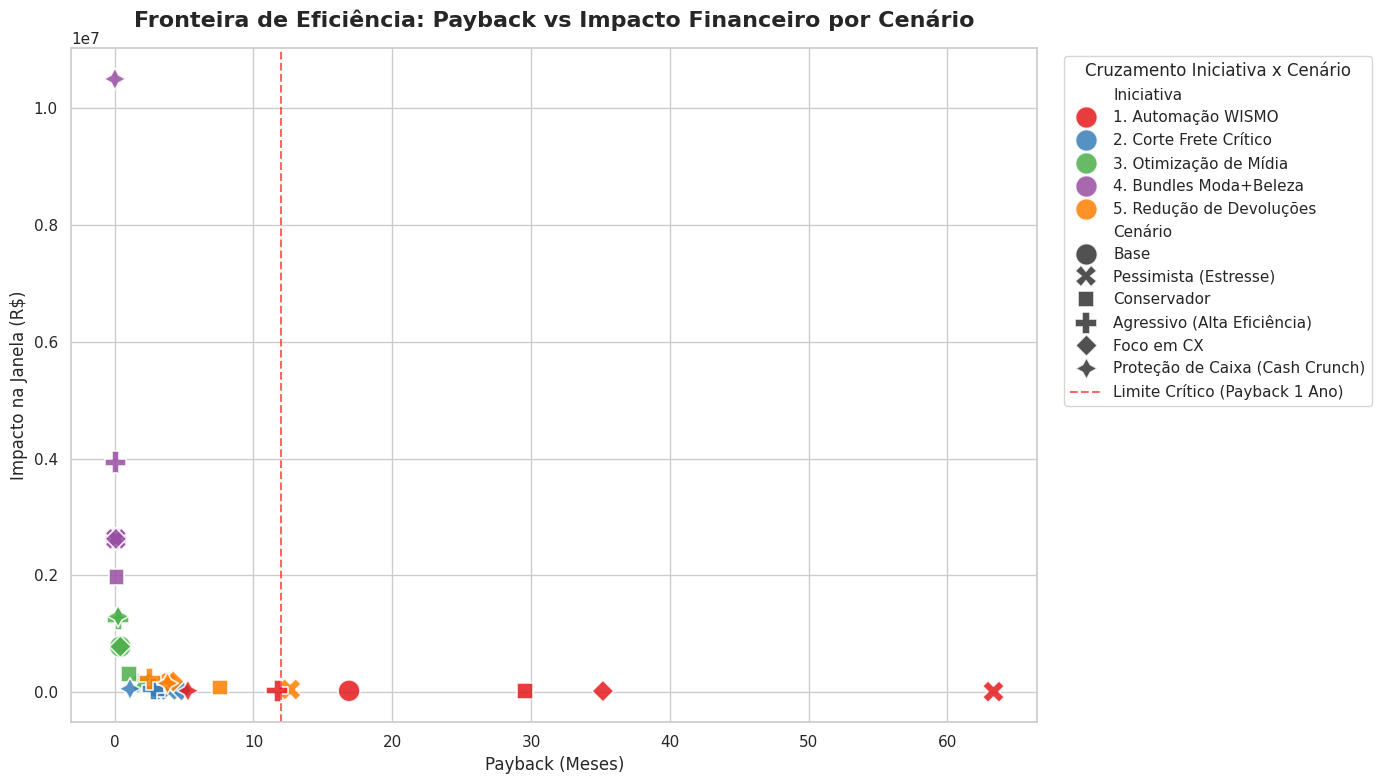

In [ ]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df_iniciativas_consolidado, 
    x='Payback (Meses)', 
    y='Impacto na Janela (R$)',
    hue='Iniciativa', 
    style='Cenário', 
    s=250, 
    palette='Set1',
    alpha=0.85
)

plt.title('Fronteira de Eficiência: Payback vs Impacto Financeiro por Cenário', fontsize=16, fontweight='bold', pad=15)
plt.axvline(x=12, color='red', linestyle='--', alpha=0.6, label='Limite Crítico (Payback 1 Ano)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, title="Cruzamento Iniciativa x Cenário")
plt.tight_layout()
plt.show()

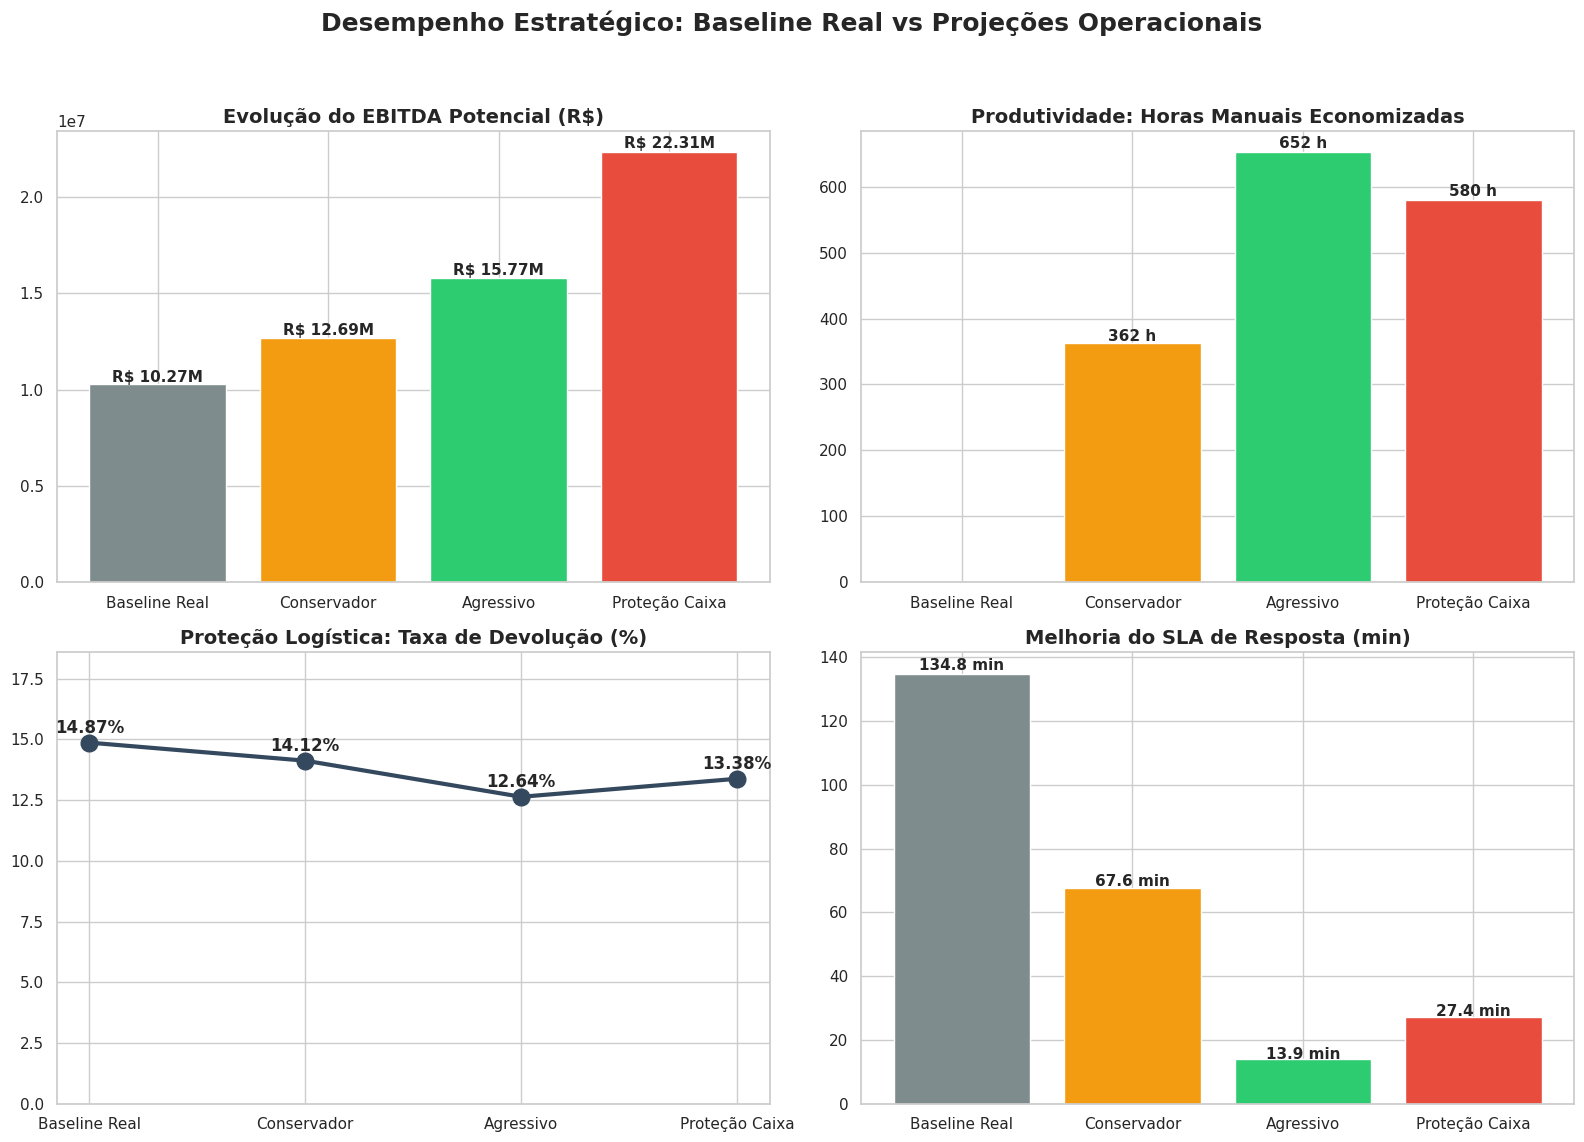

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Desempenho Estratégico: Baseline Real vs Projeções Operacionais', fontsize=18, fontweight='bold', y=0.98)

cenarios_plot = ['Baseline (Realizado)', 'Conservador', 'Agressivo (Alta Eficiência)', 'Proteção de Caixa (Cash Crunch)']
labels_plot = ['Baseline Real', 'Conservador', 'Agressivo', 'Proteção Caixa']
x_pos = np.arange(len(labels_plot))
cores = ['#7f8c8d', '#f39c12', '#2ecc71', '#e74c3c']

# 1. Expansão de EBITDA Potencial
ebitdas = [df_kpis_comparativo.loc['EBITDA Potencial (R$)', c] for c in cenarios_plot]
axes[0, 0].bar(x_pos, ebitdas, color=cores)
axes[0, 0].set_title('Evolução do EBITDA Potencial (R$)', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(labels_plot, fontsize=11)
for i, v in enumerate(ebitdas):
    axes[0, 0].text(i, v + (v * 0.01), f'R$ {v/1e6:,.2f}M', ha='center', fontweight='bold', fontsize=11)

# 2. Produtividade (Horas Economizadas)
horas = [df_kpis_comparativo.loc['Horas Economizadas', c] for c in cenarios_plot]
axes[0, 1].bar(x_pos, horas, color=cores)
axes[0, 1].set_title('Produtividade: Horas Manuais Economizadas', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(labels_plot, fontsize=11)
for i, v in enumerate(horas):
    if v > 0:
        axes[0, 1].text(i, v + (v * 0.01), f'{v:,.0f} h', ha='center', fontweight='bold', fontsize=11)

# 3. Eficiência Logística (Devoluções)
dev_rates = [df_kpis_comparativo.loc['Taxa de Devolução (%)', c] for c in cenarios_plot]
axes[1, 0].plot(x_pos, dev_rates, marker='o', markersize=12, linewidth=3, color='#34495e')
axes[1, 0].set_title('Proteção Logística: Taxa de Devolução (%)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(labels_plot, fontsize=11)
axes[1, 0].set_ylim(bottom=0, top=max(dev_rates) * 1.25)
for i, v in enumerate(dev_rates):
    axes[1, 0].text(i, v + 0.4, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)

# 4. Tempo Médio de Resposta (SLA)
slas = [df_kpis_comparativo.loc['Tempo Resposta Médio (min)', c] for c in cenarios_plot]
axes[1, 1].bar(x_pos, slas, color=cores)
axes[1, 1].set_title('Melhoria do SLA de Resposta (min)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(labels_plot, fontsize=11)
for i, v in enumerate(slas):
    axes[1, 1].text(i, v + (v * 0.01), f'{v:.1f} min', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()